[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# Tres en Raya — Mejoras al sistema de Aprendizaje por Refuerzo

Este cuadernillo parte del código original de introducción al axr y añade **cuatro mejoras concretas**:

| # | Mejora | ¿Qué problema resuelve? |
|---|--------|------------------------|
| 1 | **Wins equilibradas** | El jugador que va primero (X) tiene ventaja estructural; la corregimos alternando quién abre cada partida |
| 2 | **Reducción progresiva de la exploración** | Al inicio conviene explorar mucho; con el tiempo, explotar lo aprendido es más eficiente |
| 3 | **Visualización de una partida completa** | Permite ver gráficamente, movimiento a movimiento, cómo juegan los agentes |
| 4 | **Jugar contra un agente entrenado** | Interfaz interactiva para enfrentarse al agente desde el cuadernillo |

> **Prerequisito:** haber leído el cuadernillo `01_introduccion_explicado.ipynb`.  
> El código de las clases `Board`, `Agent` y `Game` se reproduce aquí con las modificaciones necesarias.


## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import pickle
from tqdm import tqdm

# Reproducibilidad: fijamos la semilla para que los resultados sean comparables
np.random.seed(42)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
## 1. Clase `Board` — sin cambios

El tablero no necesita modificaciones; la lógica del juego es la misma.


In [4]:
class Board():
    def __init__(self):
        self.state = np.zeros((3, 3))

    def valid_moves(self):
        return [(i, j) for j in range(3) for i in range(3) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError("movimiento ilegal !")

    def is_game_over(self):
        # filas y columnas
        if (self.state.sum(axis=0) == 3).sum() >= 1 or (self.state.sum(axis=1) == 3).sum() >= 1:
            return 1
        if (self.state.sum(axis=0) == -3).sum() >= 1 or (self.state.sum(axis=1) == -3).sum() >= 1:
            return -1
        # diagonales
        diag_sums = [
            sum([self.state[i, i] for i in range(3)]),
            sum([self.state[i, 3 - i - 1] for i in range(3)]),
        ]
        if diag_sums[0] == 3 or diag_sums[1] == 3:
            return 1
        if diag_sums[0] == -3 or diag_sums[1] == -3:
            return -1
        # empate
        if len(self.valid_moves()) == 0:
            return 0
        return None

    def reset(self):
        self.state = np.zeros((3, 3))


---
## 2. Clase `Agent` — sin cambios

La lógica de aprendizaje del agente tampoco cambia.  
`prob_exp` es un **atributo de instancia**, lo que nos permite modificarlo desde fuera de la clase  
durante el entrenamiento (clave para la mejora 2).


In [5]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {}  # tabla estado -> valor
        self.alpha = alpha
        self.positions = []
        self.prob_exp = prob_exp  # modificable externamente → clave para el decay

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        # Exploración
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        # Explotación
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(3 * 3))
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(3 * 3)))

    def reward(self, reward):
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]


---
## 3. Clase `Game` — con las mejoras 1 y 2

### Mejora 1 · Wins equilibradas

**Problema:** en el original, `player1` (X) **siempre** mueve primero.  
En el tres en raya con juego perfecto, quien va primero tiene ventaja garantizada.  
Eso hace que `wins[0]` casi siempre supere a `wins[1]`, aunque ambos agentes sean igual de buenos.

**Solución:** al inicio de cada partida, **sortear aleatoriamente** quién va primero.  
A lo largo de 300 000 partidas, cada agente abrirá aproximadamente la mitad de las veces,
igualando las oportunidades.

```
Partida 1:  orden = [player1, player2]   (player1 va primero)
Partida 2:  orden = [player2, player1]   (player2 va primero)
Partida 3:  orden = [player1, player2]   ...
...
```

---

### Mejora 2 · Reducción progresiva de la exploración (ε-decay)

**Problema:** con `prob_exp = 0.5` fijo, al final del entrenamiento el agente sigue  
tomando el 50 % de sus decisiones al azar, aunque ya ha aprendido mucho.  
Esto frena la convergencia y desperdicia partidas al final.

**Solución:** empezar con alta exploración (explorar el espacio desconocido)  
y reducirla gradualmente hasta un mínimo pequeño (aprovechar lo aprendido).

La fórmula de **decaimiento lineal** que usamos:

$$\varepsilon(i) = \varepsilon_{\text{inicio}} \cdot \left(1 - \frac{i}{N}\right) + \varepsilon_{\text{fin}} \cdot \frac{i}{N}$$

Donde $i$ es la partida actual y $N$ el total. Al principio $\varepsilon \approx \varepsilon_{\text{inicio}}$;  
al final $\varepsilon \approx \varepsilon_{\text{fin}}$.

```
Partida    1 / 300 000:  ε = 0.90  (exploración máxima)
Partida  150 000 / 300 000:  ε = 0.475 (mezcla)
Partida  300 000 / 300 000:  ε = 0.05  (exploración mínima)
```


In [6]:
class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    # ------------------------------------------------------------------ #
    #  selfplay mejorado: recibe parámetros de balance y de decay          #
    # ------------------------------------------------------------------ #
    def selfplay(self, rounds=100,
                 alternar_primero=True,          # MEJORA 1
                 prob_exp_inicio=0.9,            # MEJORA 2
                 prob_exp_fin=0.05,              # MEJORA 2
                 intervalo_registro=5000):       # para la curva de aprendizaje
        """
        Parámetros
        ----------
        rounds            : número total de partidas de entrenamiento.
        alternar_primero  : si True, sortea quién va primero en cada partida.
        prob_exp_inicio   : exploración al inicio del entrenamiento.
        prob_exp_fin      : exploración al final del entrenamiento.
        intervalo_registro: cada cuántas partidas se registra el estado del entrenamiento.
        """
        wins = [0, 0]
        empates = 0
        historial = []   # (partida, wins[0], wins[1], empates, prob_exp)

        for i in tqdm(range(1, rounds + 1)):

            # ── MEJORA 2: calcular ε para esta partida ─────────────────
            progreso = i / rounds   # 0.0 al inicio → 1.0 al final
            prob_exp_actual = prob_exp_inicio * (1 - progreso) + prob_exp_fin * progreso
            for player in self.players:
                player.prob_exp = prob_exp_actual

            # ── MEJORA 1: sortear quién va primero ─────────────────────
            if alternar_primero and np.random.random() < 0.5:
                orden = list(reversed(self.players))
            else:
                orden = self.players

            # ── Reiniciar tablero e historiales ────────────────────────
            self.board.reset()
            for player in self.players:
                player.reset()

            # ── Bucle de la partida ────────────────────────────────────
            game_over = False
            while not game_over:
                for player in orden:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for p in self.players:
                        p.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break

            # ── Recompensas ────────────────────────────────────────────
            self.reward()
            resultado = self.board.is_game_over()
            for ix, player in enumerate(self.players):
                if resultado == player.symbol:
                    wins[ix] += 1
            if resultado == 0:
                empates += 1

            # ── Registro periódico ─────────────────────────────────────
            if i % intervalo_registro == 0:
                historial.append({
                    'partida':   i,
                    'wins_p1':   wins[0],
                    'wins_p2':   wins[1],
                    'empates':   empates,
                    'prob_exp':  prob_exp_actual,
                })

        print(f"\nResultados finales tras {rounds:,} partidas:")
        print(f"  Player 1 (X): {wins[0]:,} victorias ({100*wins[0]/rounds:.1f} %)")
        print(f"  Player 2 (O): {wins[1]:,} victorias ({100*wins[1]/rounds:.1f} %)")
        print(f"  Empates:      {empates:,}  ({100*empates/rounds:.1f} %)")
        return wins, empates, historial

    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0:
            for player in self.players:
                player.reward(0.5)
        else:
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)


---
## 4. Entrenamiento con todas las mejoras

Entrenamos dos agentes con:
- `prob_exp_inicio = 0.9` → exploración agresiva al inicio.
- `prob_exp_fin = 0.05`  → casi pura explotación al final.
- `alternar_primero = True` → sorteo de quién abre cada partida.


In [8]:
agent1 = Agent(alpha=0.5)
agent2 = Agent(alpha=0.5)

#game = Game(agent1, agent2)

# wins, empates, historial = game.selfplay(
#     rounds=300_000,
#     alternar_primero=True,
#     prob_exp_inicio=0.9,
#     prob_exp_fin=0.05,
#     intervalo_registro=5_000,
# )


### Curva de aprendizaje

El historial registrado nos permite ver cómo evoluciona el entrenamiento:
- **Arriba**: victorias acumuladas de cada agente (deberían ser similares).
- **Abajo**: el valor de ε a lo largo del tiempo (decaimiento lineal).


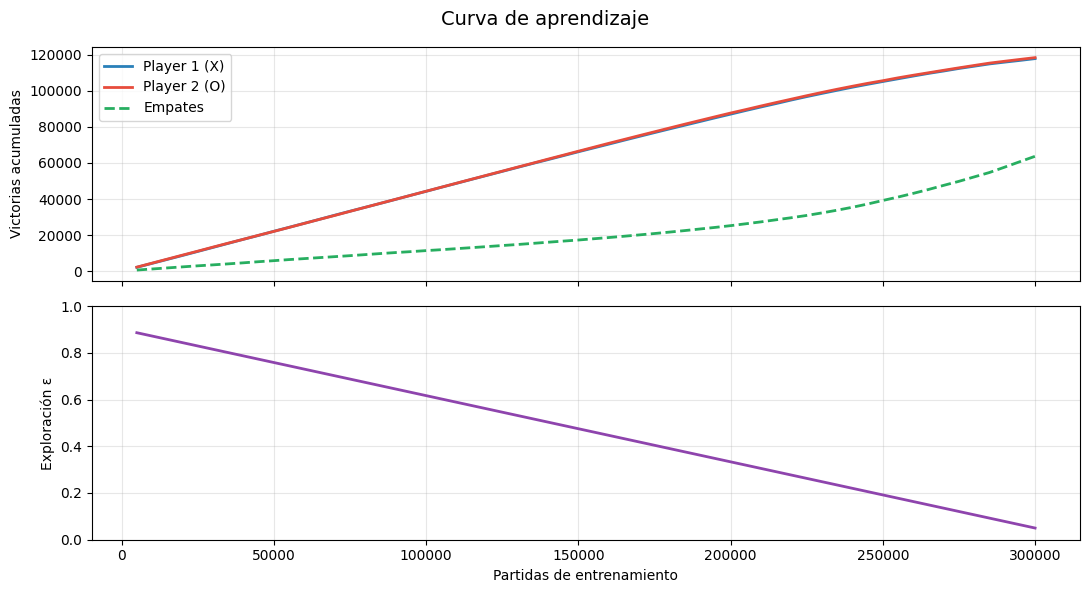


Diferencia entre victorias de ambos agentes: 548  (0.2 % del total de victorias)
Con alternar_primero=True esta diferencia debería ser significativamente menor
que en el entrenamiento original (donde siempre iba primero el mismo agente).


In [6]:
df = pd.DataFrame(historial)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig.suptitle('Curva de aprendizaje', fontsize=14, fontweight='bold')

# ── Victorias acumuladas ──────────────────────────────────────────────
ax1.plot(df['partida'], df['wins_p1'], label='Player 1 (X)', color='#2980b9', linewidth=2)
ax1.plot(df['partida'], df['wins_p2'], label='Player 2 (O)', color='#e74c3c', linewidth=2)
ax1.plot(df['partida'], df['empates'], label='Empates',       color='#27ae60', linewidth=2, linestyle='--')
ax1.set_ylabel('Victorias acumuladas')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Decaimiento de ε ─────────────────────────────────────────────────
ax2.plot(df['partida'], df['prob_exp'], color='#8e44ad', linewidth=2)
ax2.set_ylabel('Exploración ε')
ax2.set_xlabel('Partidas de entrenamiento')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diferencia de victorias al final
diff = abs(wins[0] - wins[1])
pct  = diff / sum(wins) * 100 if sum(wins) > 0 else 0
print(f"\nDiferencia entre victorias de ambos agentes: {diff:,}  ({pct:.1f} % del total de victorias)")
print("Con alternar_primero=True esta diferencia debería ser significativamente menor")
print("que en el entrenamiento original (donde siempre iba primero el mismo agente).")


### Guardar los agentes entrenados

In [ ]:
import pickle

with open('agent1.pickle', 'wb') as f:
    pickle.dump(agent1.value_function, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('agent2.pickle', 'wb') as f:
    pickle.dump(agent2.value_function, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"agent1 guardado: {len(agent1.value_function):,} estados")
print(f"agent2 guardado: {len(agent2.value_function):,} estados")


agent1 guardado: 8,532 estados
agent2 guardado: 8,532 estados


---
## 5. Mejora 3 · Visualización de una partida completa

Esta sección añade dos funciones:

- `dibujar_tablero(ax, estado, titulo, resaltar)` — dibuja un tablero en un eje de matplotlib.
- `visualizar_partida(a1, a2, explore)` — hace jugar a dos agentes y muestra cada movimiento.

El tablero se dibuja con las convenciones habituales:
- **X en azul** (jugador 1, símbolo +1).
- **O en rojo** (jugador 2, símbolo -1).
- La celda del **último movimiento** se resalta en amarillo.


In [8]:
def dibujar_tablero(ax, estado, titulo='', resaltar=None):
    """
    Dibuja un tablero 3x3 en el eje `ax`.

    Parámetros
    ----------
    ax        : eje de matplotlib donde dibujar.
    estado    : np.ndarray de forma (3,3) con valores 0, 1 o -1.
    titulo    : texto que aparece sobre el tablero.
    resaltar  : tupla (fila, col) de la celda a resaltar, o None.
    """
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.axis('off')

    # Fondo
    ax.add_patch(patches.Rectangle((0, 0), 3, 3, color='#fafafa', zorder=0))

    # Resaltar la celda del último movimiento
    if resaltar is not None:
        row, col = resaltar
        ax.add_patch(patches.Rectangle(
            (col, 2 - row), 1, 1,
            color='#fff3b0', zorder=1, linewidth=0
        ))

    # Líneas de la cuadrícula
    for k in [1, 2]:
        ax.axhline(k, color='#2c3e50', linewidth=2.5, zorder=2)
        ax.axvline(k, color='#2c3e50', linewidth=2.5, zorder=2)

    # Fichas
    for row in range(3):
        for col in range(3):
            v  = estado[row, col]
            cx = col + 0.5
            cy = 2.5 - row   # fila 0 arriba → cy más alto

            if v == 1:   # X – azul
                d = 0.27
                ax.plot([cx - d, cx + d], [cy - d, cy + d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)
                ax.plot([cx - d, cx + d], [cy + d, cy - d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)

            elif v == -1:  # O – rojo
                circ = plt.Circle((cx, cy), 0.27,
                                  fill=False, color='#e74c3c', linewidth=5, zorder=3)
                ax.add_patch(circ)

    if titulo:
        ax.set_title(titulo, fontsize=9, pad=5, fontweight='bold')


In [10]:
def visualizar_partida(agente1, agente2, explore=False):
    """
    Hace jugar a dos agentes entre sí y muestra todos los estados del tablero,
    desde el tablero vacío hasta el estado final.

    Parámetros
    ----------
    agente1 : Agent (juega con X, símbolo +1).
    agente2 : Agent (juega con O, símbolo -1).
    explore : si True, los agentes pueden explorar; si False, solo explotan.
    """
    board = Board()
    agente1.symbol = 1
    agente2.symbol = -1
    agente1.reset()
    agente2.reset()

    # Registrar el estado inicial y todos los movimientos
    snapshots = [(board.state.copy(), None, '— Inicio —')]
    jugadores  = [agente1, agente2]
    nombres    = ['X (agent1)', 'O (agent2)']
    turno      = 0

    while board.is_game_over() is None:
        jugador  = jugadores[turno % 2]
        nombre   = nombres[turno % 2]
        accion   = jugador.move(board, explore=explore)
        board.update(jugador.symbol, accion[0], accion[1])
        for p in jugadores:
            p.update(board)

        resultado = board.is_game_over()
        if resultado == 1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡X gana!'
        elif resultado == -1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡O gana!'
        elif resultado == 0:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — Empate'
        else:
            etiqueta = f'Movimiento {turno+1} ({nombre})'

        snapshots.append((board.state.copy(), accion, etiqueta))
        turno += 1

    # ── Dibujar ──────────────────────────────────────────────────────────
    n  = len(snapshots)
    nc = min(n, 5)          # máximo 5 columnas por fila
    nr = (n + nc - 1) // nc

    fig, axes = plt.subplots(nr, nc, figsize=(3 * nc, 3.2 * nr))
    axes = np.array(axes).reshape(-1) if nr * nc > 1 else [axes]

    for idx, (estado, resaltar, titulo) in enumerate(snapshots):
        dibujar_tablero(axes[idx], estado, titulo=titulo, resaltar=resaltar)

    # Ocultar ejes sobrantes
    for idx in range(len(snapshots), len(axes)):
        axes[idx].axis('off')

    resultado_final = board.is_game_over()
    suptitulo = {1: '🏆 ¡Gana X (agent1)!', -1: '🏆 ¡Gana O (agent2)!', 0: '🤝 ¡Empate!'}
    fig.suptitle(suptitulo.get(resultado_final, ''), fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.show()
    return resultado_final


### Demostración: una partida completa entre los dos agentes

Ejecutamos `visualizar_partida` **sin exploración** (`explore=False`) para ver  
cómo juegan los agentes con la política que aprendieron.

Cada tablero muestra el estado tras cada movimiento. La celda resaltada en amarillo  
indica dónde se colocó la ficha en ese turno.


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_10404\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


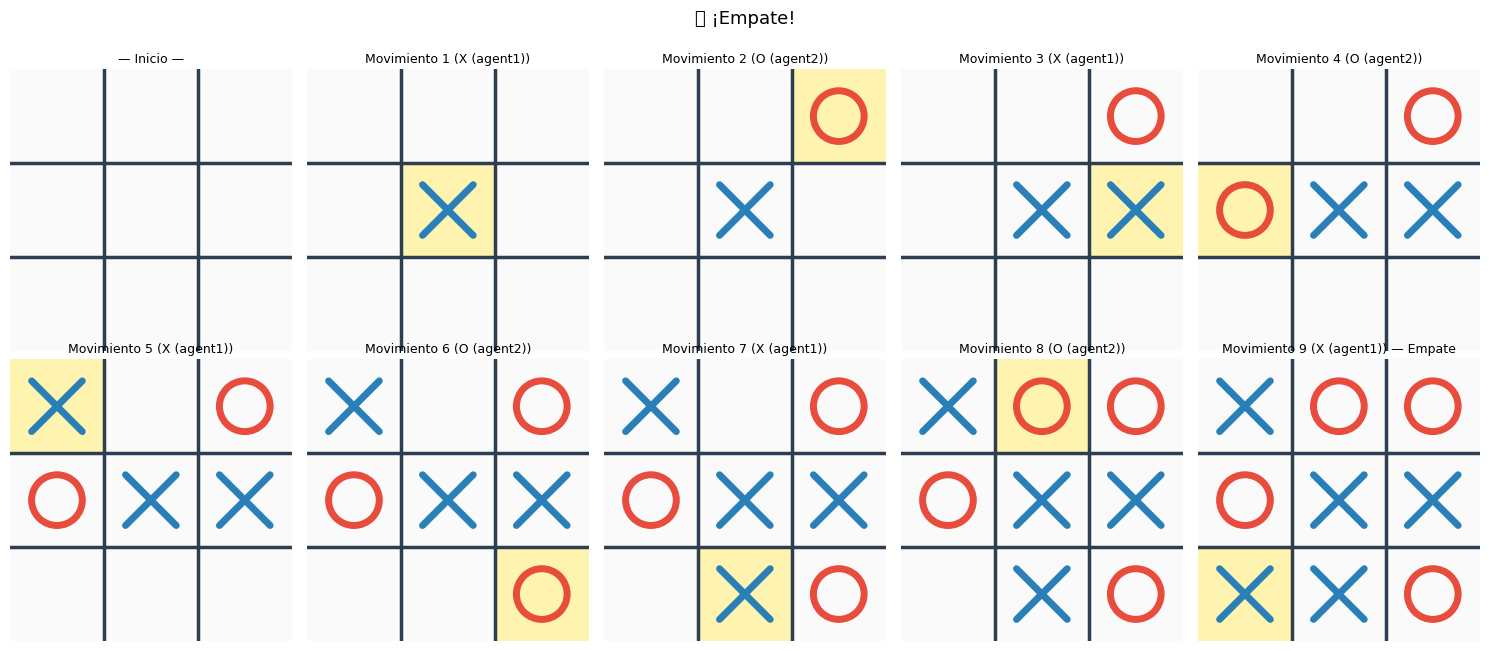

In [41]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)


Partida entre agent1 (X) y agent2 (O) — con exploración (prob_exp actual):


C:\Users\aaran\AppData\Local\Temp\ipykernel_10404\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


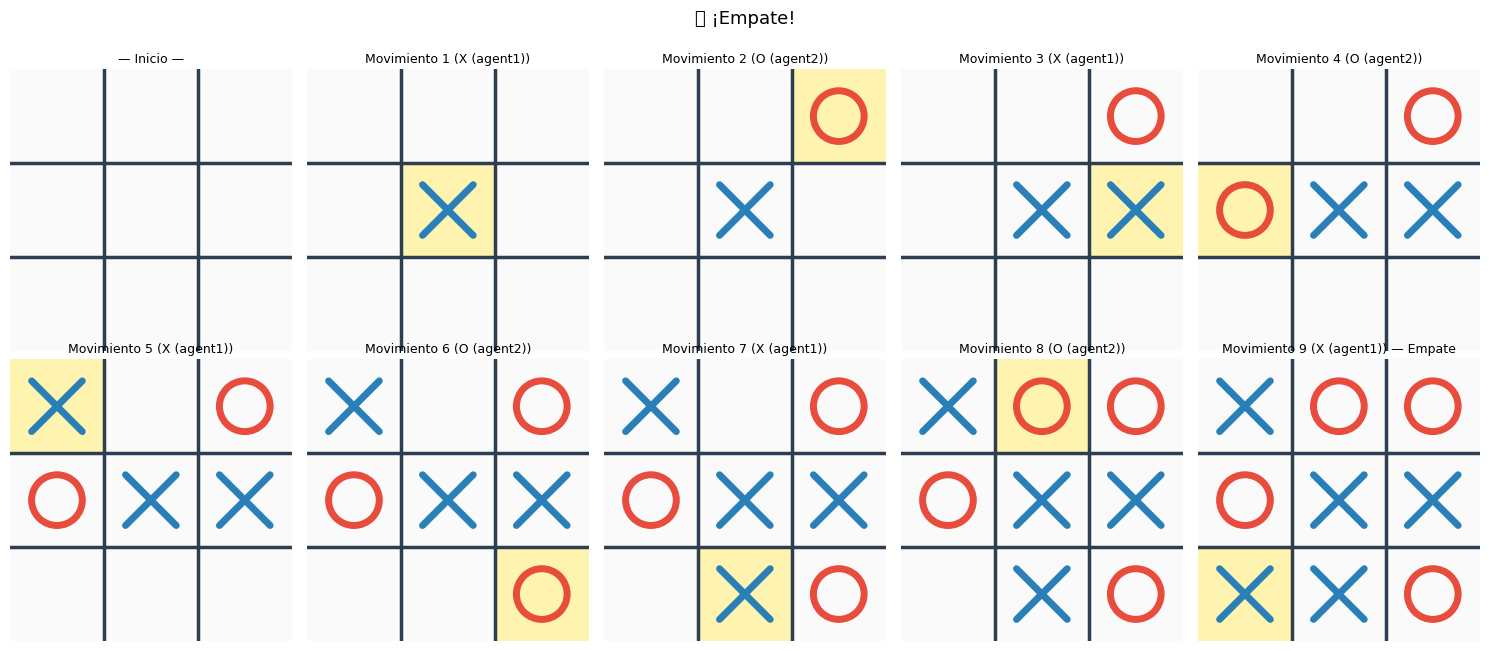

In [47]:
# Partida con exploración → comportamiento más variado, útil para ver diversidad
print("Partida entre agent1 (X) y agent2 (O) — con exploración (prob_exp actual):")
resultado = visualizar_partida(agent1, agent2, explore=True)


Muestra de 5 resultados consecutivos (sin exploración):
  Partida 1: 

C:\Users\aaran\AppData\Local\Temp\ipykernel_10404\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


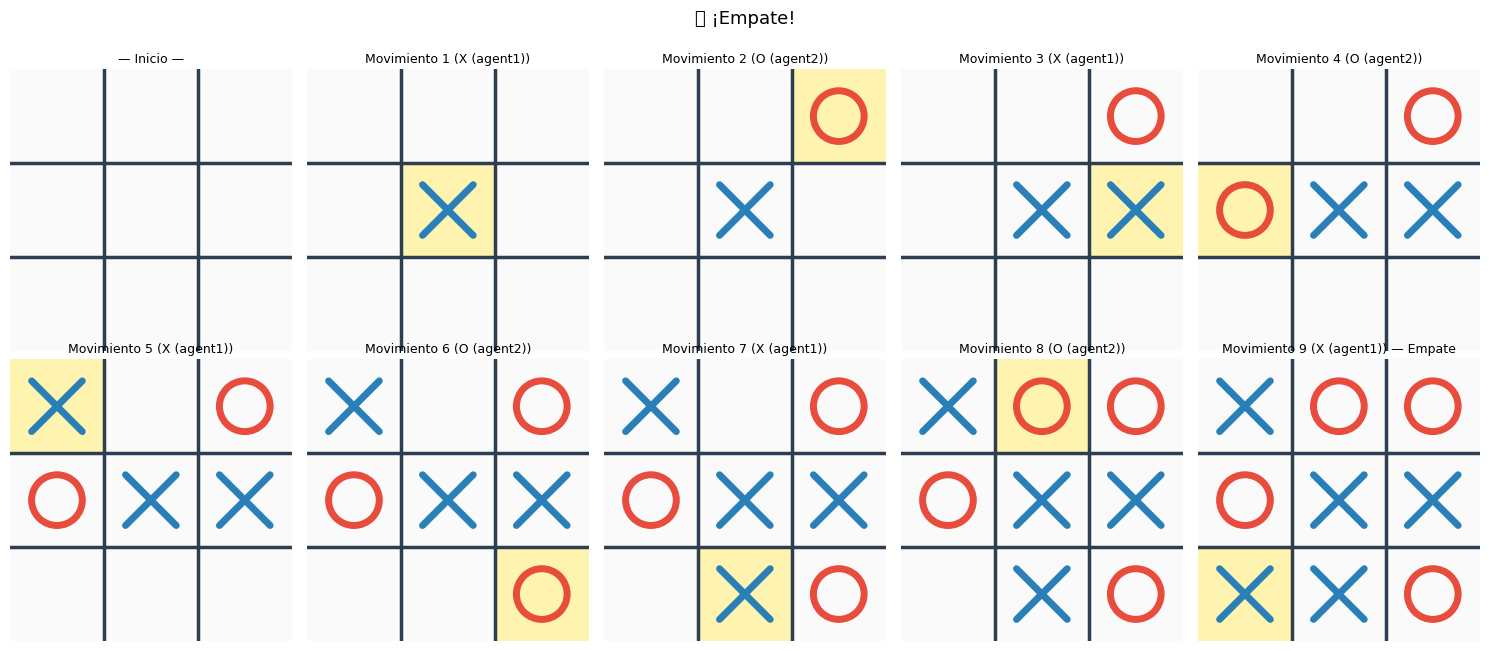

  Partida 2: 

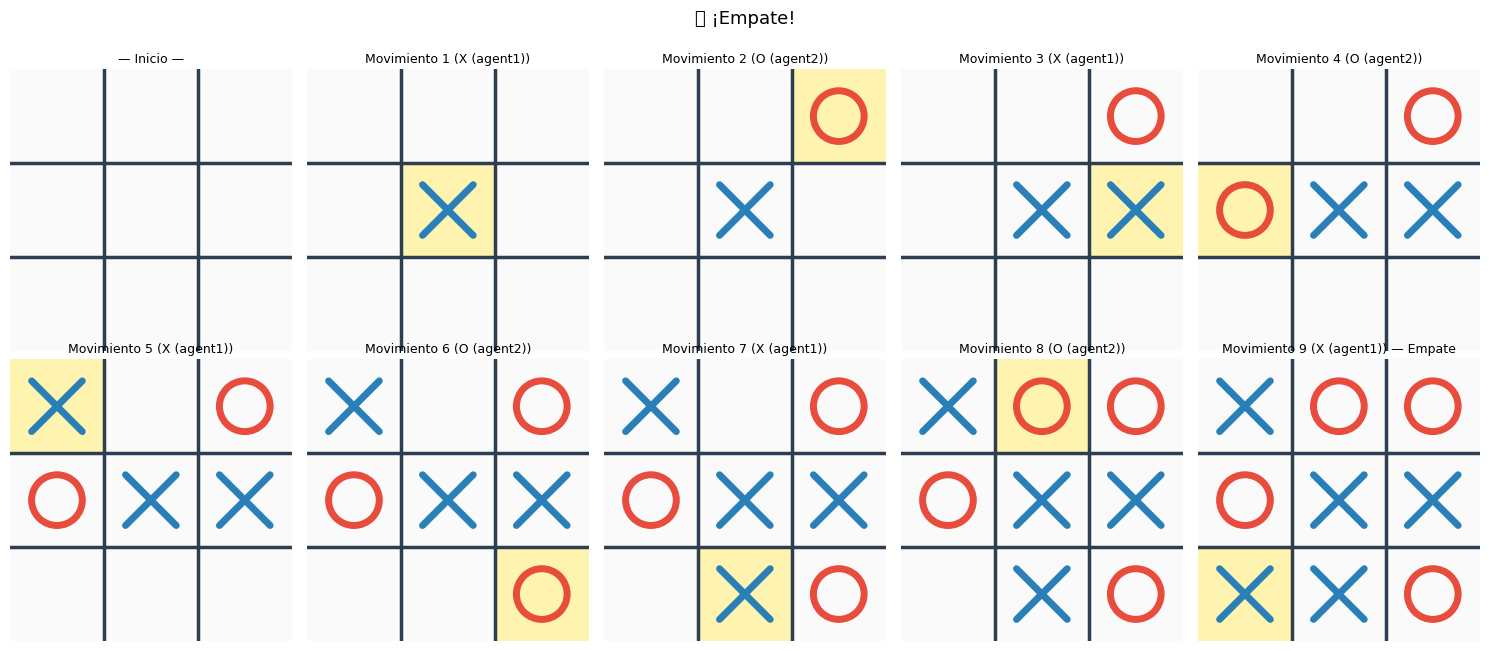

  Partida 3: 

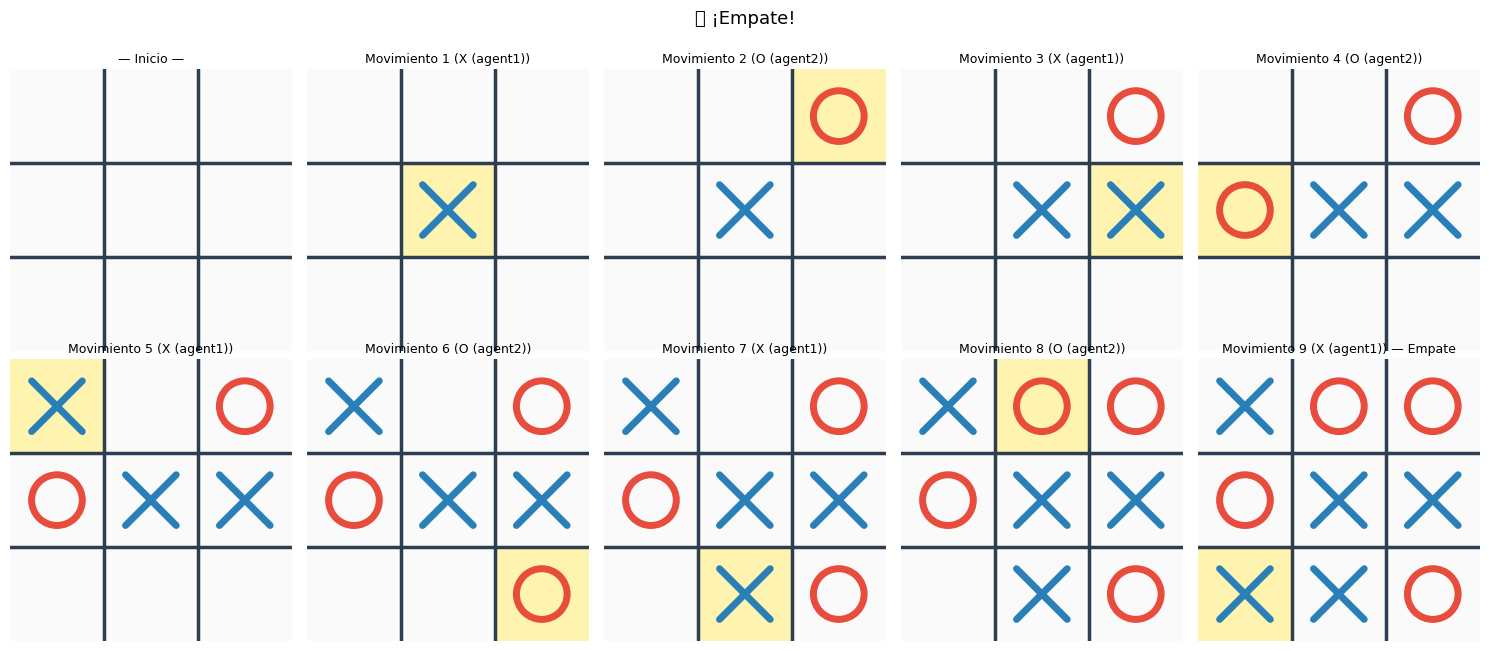

  Partida 4: 

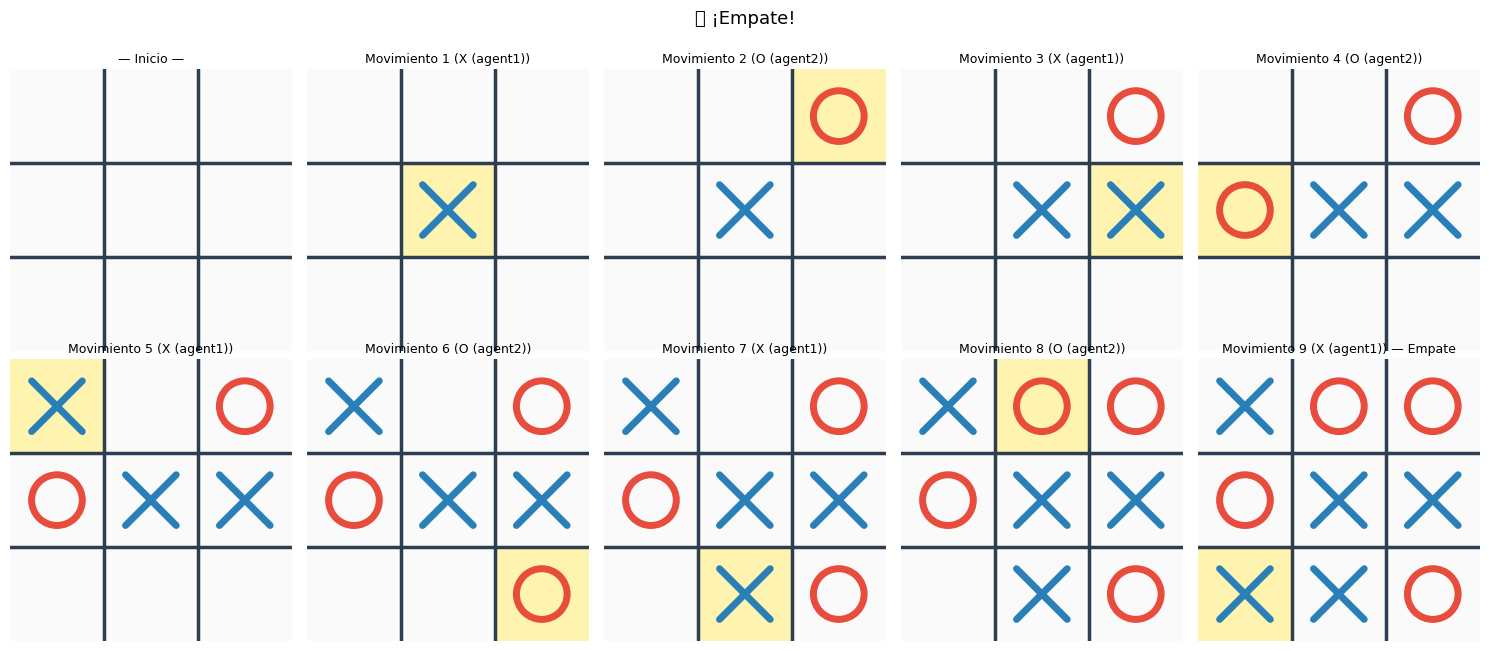

  Partida 5: 

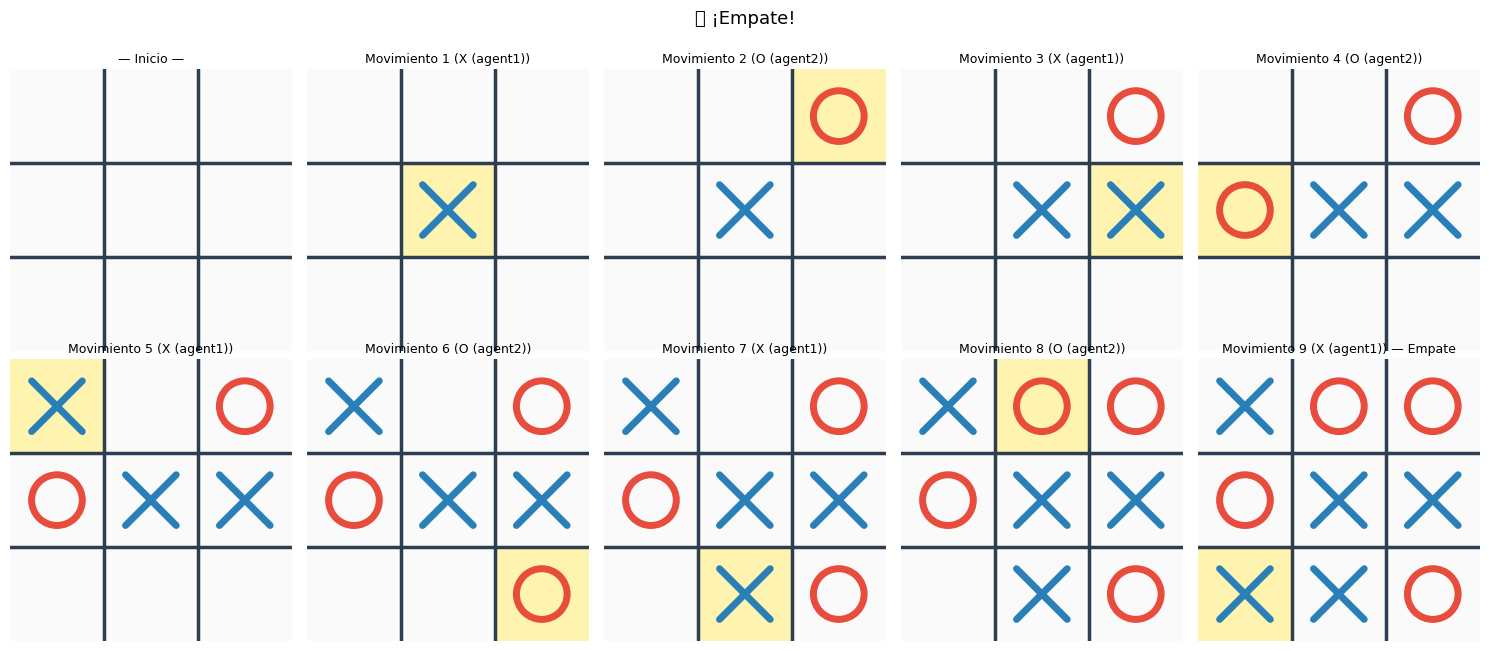


Resumen:
  Empate: 5 vez/veces


In [48]:
# Demostración: visualizar varias partidas para ver variabilidad
print("Muestra de 5 resultados consecutivos (sin exploración):")
resultados = []
for i in range(5):
    board_tmp = Board()
    a1_tmp, a2_tmp = Agent(), Agent()
    a1_tmp.value_function = agent1.value_function
    a2_tmp.value_function = agent2.value_function
    a1_tmp.symbol, a2_tmp.symbol = 1, -1
    print(f"  Partida {i+1}:", end=' ')
    res = visualizar_partida(a1_tmp, a2_tmp, explore=False)
    resultados.append(res)

etiquetas = {1: 'X gana', -1: 'O gana', 0: 'Empate'}
from collections import Counter
conteo = Counter(resultados)
print("\nResumen:")
for k, v in conteo.items():
    print(f"  {etiquetas[k]}: {v} vez/veces")


---
## 6. Mejora 4 · Jugar contra un agente entrenado

La función `jugar_contra_agente` permite al usuario enfrentarse al agente  
de forma interactiva desde el cuadernillo.

**Cómo funciona:**
1. El tablero se muestra gráficamente con matplotlib antes de cada turno.
2. Cuando es tu turno, el sistema lista los movimientos válidos y pide tu jugada.
3. El agente responde inmediatamente (sin exploración — usa lo que aprendió).
4. Al final se declara el ganador y se muestra el tablero final.

**Formato de entrada:** `fila,columna` (sin espacios, ambas de 0 a 2).  
Ejemplo: `1,1` coloca tu ficha en el centro.

```
Posiciones del tablero:
  (0,0) | (0,1) | (0,2)
  ──────┼───────┼──────
  (1,0) | (1,1) | (1,2)
  ──────┼───────┼──────
  (2,0) | (2,1) | (2,2)
```


In [1]:
def jugar_contra_agente(agente_entrenado, juega_primero=True):
    """
    Partida interactiva: el usuario vs. el agente entrenado.

    Parámetros
    ----------
    agente_entrenado : Agent con value_function ya cargada.
    juega_primero    : True  → el humano juega con X y va primero.
                       False → el humano juega con O y va segundo.
    """
    board   = Board()
    agente_entrenado.reset()

    simbolo_humano = 1 if juega_primero else -1
    simbolo_agente = -simbolo_humano
    agente_entrenado.symbol = simbolo_agente

    nombre_humano = 'X (tú)'  if simbolo_humano ==  1 else 'O (tú)'
    nombre_agente = 'X (agente)' if simbolo_agente == 1 else 'O (agente)'

    print("=" * 45)
    print("   🎮  TRES EN RAYA — Tú vs. el Agente")
    print("=" * 45)
    print(f"  Tú juegas con: {'X (azul)' if simbolo_humano == 1 else 'O (rojo)'}")
    print(f"  Agente juega con: {'X (azul)' if simbolo_agente == 1 else 'O (rojo)'}")
    print(f"  Referencia de celdas:")
    print("    (0,0)|(0,1)|(0,2)")
    print("    (1,0)|(1,1)|(1,2)")
    print("    (2,0)|(2,1)|(2,2)")
    print()

    # X siempre va primero (símbolo +1)
    turno_x = True   # True = es el turno del jugador X

    ultimo_mov = None

    while board.is_game_over() is None:
        # Determinar de quién es el turno
        if turno_x:
            simbolo_turno = 1
            es_humano     = (simbolo_humano == 1)
        else:
            simbolo_turno = -1
            es_humano     = (simbolo_humano == -1)

        nombre_turno = nombre_humano if es_humano else nombre_agente

        # Mostrar tablero actual
        fig, ax = plt.subplots(figsize=(3.2, 3.2))
        dibujar_tablero(ax, board.state,
                        titulo=f'Turno de: {nombre_turno}',
                        resaltar=ultimo_mov)
        plt.tight_layout()
        plt.show()

        if es_humano:
            # ── Turno del humano ─────────────────────────────────────
            movimientos_validos = board.valid_moves()
            print(f"Movimientos válidos: {movimientos_validos}")
            while True:
                try:
                    entrada = input("Tu jugada → fila,columna  (ej: 1,1): ").strip()
                    partes  = entrada.split(',')
                    fila, col = int(partes[0]), int(partes[1])
                    if (fila, col) in movimientos_validos:
                        break
                    print(f"  ⚠ ({fila},{col}) no es un movimiento válido. Intenta de nuevo.")
                except Exception:
                    print("  ⚠ Formato incorrecto. Usa: fila,columna  (ej: 1,1)")

            board.update(simbolo_humano, fila, col)
            ultimo_mov = (fila, col)
            print(f"  ✓ Colocaste tu ficha en ({fila},{col}).")

        else:
            # ── Turno del agente ─────────────────────────────────────
            accion = agente_entrenado.move(board, explore=False)
            board.update(simbolo_agente, accion[0], accion[1])
            ultimo_mov = accion
            print(f"  🤖 El agente jugó en ({accion[0]},{accion[1]}).")

        agente_entrenado.update(board)
        turno_x = not turno_x
        print()

    # ── Tablero final ─────────────────────────────────────────────────────
    resultado = board.is_game_over()
    if resultado == simbolo_humano:
        titulo_final = '🏆 ¡GANASTE!'
        msg_final    = '¡Enhorabuena, venciste al agente!'
    elif resultado == simbolo_agente:
        titulo_final = '🤖 El agente ganó'
        msg_final    = 'El agente ganó esta vez. ¡Inténtalo de nuevo!'
    else:
        titulo_final = '🤝 ¡EMPATE!'
        msg_final    = '¡Buen juego, terminaron en empate!'

    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    dibujar_tablero(ax, board.state, titulo=titulo_final, resaltar=ultimo_mov)
    plt.tight_layout()
    plt.show()

    print("=" * 45)
    print(f"  {titulo_final}")
    print(f"  {msg_final}")
    print("=" * 45)


### ¡A jugar!

Ejecuta la celda siguiente y sigue las instrucciones.

- `juega_primero=True`  → empiezas tú (X).  
- `juega_primero=False` → empieza el agente (X), tú juegas con O.

Puedes cambiar `agent1` por `agent2` para enfrentarte al segundo agente.


In [13]:
# Cargar agente desde archivo (útil si reinicias el kernel)
agente_para_jugar = Agent(prob_exp=0.0)   # sin exploración al jugar
agente_para_jugar.value_function = agent1.value_function.copy()

# ── ¡Cambia juega_primero=True/False para elegir tu turno! ──────────────────
jugar_contra_agente(agente_para_jugar, juega_primero=True)


   🎮  TRES EN RAYA — Tú vs. el Agente
  Tú juegas con: X (azul)
  Agente juega con: O (rojo)
  Referencia de celdas:
    (0,0)|(0,1)|(0,2)
    (1,0)|(1,1)|(1,2)
    (2,0)|(2,1)|(2,2)



AttributeError: module 'matplotlib' has no attribute 'subplots'

---
## 7. Comparativa: original vs. versión mejorada

Para cuantificar el efecto de las mejoras, entrenamos un agente con el  
método **original** (sin alternancia, sin decay) y comparamos los resultados.


In [ ]:
# ── Agentes con método ORIGINAL ───────────────────────────────────────────
print("Entrenando con método ORIGINAL (player1 siempre primero, ε fijo = 0.5)...")
ag_orig1 = Agent(alpha=0.5, prob_exp=0.5)
ag_orig2 = Agent(alpha=0.5, prob_exp=0.5)

class GameOriginal(Game):
    def selfplay_original(self, rounds=100):
        wins = [0, 0]
        empates = 0
        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for p in self.players:
                        p.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            resultado = self.board.is_game_over()
            for ix, player in enumerate(self.players):
                if resultado == player.symbol:
                    wins[ix] += 1
            if resultado == 0:
                empates += 1
        return wins, empates

game_orig = GameOriginal(ag_orig1, ag_orig2)
wins_orig, emp_orig = game_orig.selfplay_original(rounds=300_000)

# ── Comparativa ────────────────────────────────────────────────────────────
total = 300_000
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparativa: original vs. mejorado', fontsize=13, fontweight='bold')

for ax, (w, e, titulo) in zip(axes, [
    (wins_orig, emp_orig, 'Original\n(primer jugador fijo, ε = 0.5)'),
    (wins,      empates,  'Mejorado\n(alternancia + ε-decay 0.9→0.05)'),
]):
    categorias = ['Player 1 (X)', 'Player 2 (O)', 'Empates']
    valores    = [w[0], w[1], e]
    colores    = ['#2980b9', '#e74c3c', '#27ae60']
    bars = ax.bar(categorias, valores, color=colores, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f'{val:,}\n({100*val/total:.1f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, total * 0.7)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Partidas')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

dif_orig     = abs(wins_orig[0] - wins_orig[1])
dif_mejorado = abs(wins[0]      - wins[1])
print(f"Diferencia de victorias entre agentes:")
print(f"  Original : {dif_orig:,}  ({100*dif_orig/total:.2f} %)")
print(f"  Mejorado : {dif_mejorado:,}  ({100*dif_mejorado/total:.2f} %)")
print(f"Reducción del desequilibrio: {100*(dif_orig-dif_mejorado)/max(dif_orig,1):.1f} %")


---
## Resumen de las cuatro mejoras

| Mejora | Cambio en el código | Efecto observable |
|--------|---------------------|-------------------|
| **1. Wins equilibradas** | `selfplay` sortea `orden` en cada partida | Las victorias de ambos agentes convergen |
| **2. ε-decay** | `prob_exp` cae linealmente de 0.9 a 0.05 | Mayor exploración al inicio, mayor explotación al final → convergencia más rápida |
| **3. Visualización** | `dibujar_tablero` + `visualizar_partida` | Tablero gráfico movimiento a movimiento |
| **4. Jugar** | `jugar_contra_agente` con `input()` | Interfaz interactiva completa |

Estos cambios son **modulares e independientes**: puedes activar o desactivar  
cada uno ajustando los parámetros de `selfplay` o comentando las llamadas relevantes.
